# Wave 1 Data Cleaning
## Capstone Project — Student High School Dropout Prediction

**Dataset:** HSLS:09 (High School Longitudinal Study of 2009) — Base Year (Wave 1, 9th Grade)

**Target Variable:** `X4EVERDROP` — Whether the student ever dropped out of high school (1 = Yes, 0 = No)

**Goal:** Produce one clean output file from the raw Wave 1 data:
- `9thCLEANED.csv` — a clean dataset ready for Exploratory Data Analysis (EDA)



---

## Sentinel Code Reference

The HSLS:09 dataset uses negative integer codes to represent special non-response conditions. These are called **sentinel codes**.

| Code | Meaning |
|------|---------|
| `-9` | **Item non-response** — the survey respondent was presented with the question but did not answer it |
| `-8` | **Unit non-response** — the respondent did not participate in the survey session at all |
| `-7` | **Legitimate skip** — the question did not apply to this respondent (e.g., not enrolled in math) |




---
# Section 1 — Imports and Setup

All required libraries are loaded here. These cover data manipulation, visualization, statistical testing, imputation, and machine learning preprocessing.

In [ ]:
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics and Preprocessing
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Modeling and Feature Selection
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

# Metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    classification_report
)

---
# Section 2 — Load and Select Data

The raw dataset is loaded and two column subsets are defined:

1. A broad combined set covering both Wave 1 (9th grade) and Wave 2 (11th grade) variables — saved as `columns_9th_11th.csv` for reference.
2. A focused Wave 1-only set (`wave1_columns`) that will be used throughout this notebook. This subset includes the target variable, academic measures, student and parent survey responses, socioeconomic indicators, and post-high school plan variables.

In [ ]:
df = pd.read_csv("original_dataset_withoutWieght_withoutNegativesInTarget.csv")

In [ ]:
selected_columns = [
    # Main columns
    "X1MTHEFF", "X2MTHEFF", "X1SCIEFF", "X2SCIEFF",
    "X1TXMTSCOR", "X2TXMTSCOR",
    "S1M8", "S1M8GRADE", "S1S8", "S1S8GRADE",
    "X1PAREDU", "X1PAREDEXPCT", "X2PAREDEXPCT",
    "X1STUEDEXPCT", "X2STUEDEXPCT",
    "X1SCHOOLBEL", "X2BEHAVEIN",
    "S1PLAN", "X1SCHOOLCLI", "X2PROBLEM",
    "X1PARPATTERN", "X1POVERTY", "X2POVERTY",
    "X1LOCALE", "X1RACE", "X2SEX",
    "X1CONTROL", "X1REGION",
    "S2GRD1011", "S2GRD1112", "S2ENROLLHS12",
    "X2REQLEVEL", "S2SUREDIPL",
    "C2AVGACTENG", "C2AVGACTMATH", "C2AVGSATMATH",
    "C2AVGACTSCI", "C2AVGACTCOMP", "C2AVGSATREAD",
    "C2AVGACTREAD", "C2AVGSATWRIT",
    "S2ALG1GRADE", "S2REQTYP4YR",
    "C2AIDFLYER", "S2EDUEXP", "S1EDUEXPECT",
    "C2PCTEXAMINFO", "C2GRADPLAN", "C2INFOSESSN",
    "C2SELECTCLG", "S1SUREHSGRAD", "C2PCTINFO",
    "C2UPMCLGREQ", "C2INFSTEM", "C2UPMEOGEXAM",
    "C2UPMGRADREQ", "C2PCTEXAMPREP", "C2CLGAPP",
    "X1PAR2OCC2", "X1PAR1OCC2",
    "X4EVERDROP", "X1FAMINCOME",

    # Date columns
    "X1SQDATE", "X2SQDATE",

    # Post-high school plan indicators
    "S1FYAA", "S1FYBA", "S1FYLICENSE", "S1FYAPPR",
    "S1FYMILITARY", "S1FYJOB", "S1FYFAMILY",
    "S1FYTRAVEL", "S1FYVOLUN", "S1FYNOTSURE",

    # Beliefs and attitudes
    "S1PAYOFF", "S2PAYOFF", "S2DOOKAY",
    "S1GETINTOCLG", "S1AFFORD", "S1WORKING",
    "S1SURECLG", "S1ABILITYBA",

    # Additional variables
    "S2CLG2013", "S2MOSTIMP2013", "X2ENROLSTAT",
    "STU_ID"
]

df_selected = df[selected_columns]
df_selected.to_csv("columns_9th_11th.csv", index=False)
print(f"Broad selection shape: {df_selected.shape}")

Broad selection shape: (17332, 86)


In [ ]:
wave1_columns = [
    "X4EVERDROP",          # Target variable — ever dropped out

    # Academic performance (continuous scales)
    "X1MTHEFF", "X1SCIEFF", "X1TXMTSCOR",

    # 8th grade course enrollment and grades
    "S1M8", "S1M8GRADE", "S1S8", "S1S8GRADE",

    # Parent background
    "X1PAREDU", "X1PAREDEXPCT",
    "X1PARPATTERN", "X1POVERTY",
    "X1PAR2OCC2", "X1PAR1OCC2",
    "X1FAMINCOME",

    # Student expectations and attitudes
    "X1STUEDEXPCT",
    "S1PLAN", "S1EDUEXPECT", "S1SUREHSGRAD",
    "S1PAYOFF", "S1GETINTOCLG", "S1AFFORD", "S1WORKING",
    "S1SURECLG", "S1ABILITYBA",

    # School environment
    "X1SCHOOLBEL", "X1SCHOOLCLI",

    # Demographics and school characteristics
    "X1LOCALE", "X1RACE", "X2SEX",
    "X1CONTROL", "X1REGION",

    # Date (for data leakage check)
    "X1SQDATE",

    # Post-high school plan indicators
    "S1FYAA", "S1FYBA", "S1FYLICENSE", "S1FYAPPR",
    "S1FYMILITARY", "S1FYJOB", "S1FYFAMILY",
    "S1FYTRAVEL", "S1FYVOLUN", "S1FYNOTSURE",

    # Student ID
    "STU_ID"
]

wave1 = df[wave1_columns].copy()
print(f"Wave 1 dataset shape: {wave1.shape}")

Wave 1 dataset shape: (17332, 44)


---
# Section 3 — Initial Data Inspection

Before any cleaning, we examine the raw structure of the dataset: data types, value ranges, and the distribution of sentinel codes across all columns. This step establishes a baseline and informs all subsequent decisions.

## 3.1 Data Types and Memory Overview

In [ ]:
wave1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17332 entries, 0 to 17331
Data columns (total 44 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   X4EVERDROP    17332 non-null  float64
 1   X1MTHEFF      17332 non-null  float64
 2   X1SCIEFF      17332 non-null  float64
 3   X1TXMTSCOR    17332 non-null  float64
 4   S1M8          17332 non-null  float64
 5   S1M8GRADE     17332 non-null  float64
 6   S1S8          17332 non-null  float64
 7   S1S8GRADE     17332 non-null  float64
 8   X1PAREDU      17332 non-null  float64
 9   X1PAREDEXPCT  17332 non-null  float64
 10  X1PARPATTERN  17332 non-null  float64
 11  X1POVERTY     17332 non-null  float64
 12  X1PAR2OCC2    17332 non-null  float64
 13  X1PAR1OCC2    17332 non-null  float64
 14  X1FAMINCOME   17332 non-null  float64
 15  X1STUEDEXPCT  17332 non-null  float64
 16  S1PLAN        17332 non-null  float64
 17  S1EDUEXPECT   17332 non-null  float64
 18  S1SUREHSGRAD  17332 non-nu

In [ ]:
wave1.describe()

,X4EVERDROP,X1MTHEFF,X1SCIEFF,X1TXMTSCOR,S1M8,S1M8GRADE,S1S8,S1S8GRADE,X1PAREDU,X1PAREDEXPCT,...,S1FYBA,S1FYLICENSE,S1FYAPPR,S1FYMILITARY,S1FYJOB,S1FYFAMILY,S1FYTRAVEL,S1FYVOLUN,S1FYNOTSURE,STU_ID
count,17332.000000,17332.000000,17332.000000,17332.000000,17332.000000,17332.000000,17332.000000,17332.000000,17332.000000,17332.000000,...,17332.000000,17332.000000,17332.000000,17332.000000,17332.000000,17332.000000,17332.000000,17332.000000,17332.000000,17332.000000
mean,0.156589,-1.396449,-1.826255,47.073627,2.313466,0.950554,6.138530,0.754847,0.623298,3.668821,...,-0.296850,-0.687861,-0.769617,-0.727614,-0.428802,-0.742096,-0.689188,-0.716363,-0.686303,22572.822813
std,0.363423,3.180620,3.403449,19.076769,3.711371,3.171794,5.662076,3.284320,5.047427,6.976659,...,2.632663,2.480893,2.440062,2.461463,2.589054,2.454187,2.480257,2.467042,2.481638,7260.422795
min,0.000000,-9.000000,-9.000000,-8.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,...,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,10001.000000
25%,0.000000,-1.410000,-2.910000,43.380300,1.000000,1.000000,5.000000,1.000000,1.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16307.250000
50%,0.000000,-0.170000,-0.170000,50.750500,3.000000,2.000000,9.000000,2.000000,2.000000,6.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22579.500000
75%,0.000000,0.490000,0.250000,58.320800,4.000000,2.000000,9.000000,2.000000,4.000000,10.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,28836.250000
max,1.000000,1.620000,1.830000,82.187600,9.000000,6.000000,13.000000,6.000000,7.000000,11.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35206.000000


## 3.2 Unique Values per Column (Including Sentinel Codes)

This loop prints every value and its count for each column. The `dropna=False` argument ensures sentinel codes such as -8 and -9 are visible before any replacement.

In [ ]:
for col in wave1.columns:
    print(f"--- Unique Values & Counts for: {col} ---")
    print(wave1[col].value_counts(dropna=False).sort_index())
    print("\n" + "="*40 + "\n")

--- Unique Values & Counts for: X4EVERDROP ---
X4EVERDROP
0.0    14618
1.0     2714
Name: count, dtype: int64


--- Unique Values & Counts for: X1MTHEFF ---
X1MTHEFF
-9.00     391
-8.00    1426
-7.00    1476
-2.92     216
-2.65      10
         ... 
 1.17      56
 1.21     144
 1.23      91
 1.34     480
 1.62    1872
Name: count, Length: 162, dtype: int64


--- Unique Values & Counts for: X1SCIEFF ---
X1SCIEFF
-9.00     380
-8.00    1426
-7.00    2526
-2.91     177
-2.60       8
         ... 
 1.40      46
 1.41      87
 1.42     139
 1.53     294
 1.83    1203
Name: count, Length: 150, dtype: int64


--- Unique Values & Counts for: X1TXMTSCOR ---
X1TXMTSCOR
-8.0000     1426
 24.0999       1
 24.3158       1
 24.4047       1
 24.5205       1
            ... 
 80.6105       2
 80.9568       1
 81.0926       1
 81.1870       1
 82.1876      19
Name: count, Length: 15508, dtype: int64


--- Unique Values & Counts for: S1M8 ---
S1M8
-9.0     107
-8.0    1426
-7.0      82
 1.0    3017
 2.0

In [ ]:
wave1.head()

,X4EVERDROP,X1MTHEFF,X1SCIEFF,X1TXMTSCOR,S1M8,S1M8GRADE,S1S8,S1S8GRADE,X1PAREDU,X1PAREDEXPCT,...,S1FYBA,S1FYLICENSE,S1FYAPPR,S1FYMILITARY,S1FYJOB,S1FYFAMILY,S1FYTRAVEL,S1FYVOLUN,S1FYNOTSURE,STU_ID
0,0.0,0.95,1.10,59.3710,4.0,1.0,5.0,1.0,5.0,6.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10001
1,0.0,0.55,0.69,47.6821,1.0,2.0,9.0,1.0,3.0,6.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,10002
2,0.0,0.68,-0.05,64.2431,4.0,3.0,11.0,2.0,7.0,10.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10003
3,0.0,0.10,0.25,49.2690,4.0,1.0,-9.0,-9.0,4.0,10.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10004
4,1.0,0.10,0.25,62.5897,4.0,2.0,11.0,1.0,4.0,10.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,10005


---
# Section 4 — Column Removal and Justification

Before cleaning values, we first remove columns that are not suitable for modeling. Each removal is justified below. Removing redundant or low-quality columns early simplifies all subsequent steps.

## 4.1 Remove Redundant Expectation Variables

`S1SURECLG` (certainty of attending college) and `S1ABILITYBA` (perceived ability to complete a Bachelor's degree) overlap conceptually with other features that already capture educational plans more directly, such as `S1FYBA` (plans to enroll in a Bachelor's program). Keeping these alongside the more specific plan columns would introduce redundancy without adding predictive value.

In [ ]:
wave1 = wave1.drop(columns=["S1SURECLG", "S1ABILITYBA"])
print(f"Shape after dropping S1SURECLG and S1ABILITYBA: {wave1.shape}")

Shape after dropping S1SURECLG and S1ABILITYBA: (17332, 42)


## 4.2 Remove 8th Grade Course Enrollment Indicators

`S1M8` (enrolled in 8th grade math) and `S1S8` (enrolled in 8th grade science) are binary flags with low correlation to the target. Treating them as ordinal would impose a false ordering on a nominal distinction. They are dropped in favour of the corresponding grade variables `S1M8GRADE` and `S1S8GRADE`, which carry more information.

In [ ]:
wave1 = wave1.drop(columns=["S1M8", "S1S8"])
print(f"Shape after dropping S1M8 and S1S8: {wave1.shape}")

Shape after dropping S1M8 and S1S8: (17332, 40)


## 4.3 Remove Duplicate Student Expectation Variable

`X1STUEDEXPCT` and `S1EDUEXPECT` both measure how far the student expects to go in school. The two variables are equivalent, but `S1EDUEXPECT` has a stronger correlation with the dropout target. `X1STUEDEXPCT` is removed to eliminate the duplicate.

In [ ]:
wave1 = wave1.drop(columns=["X1STUEDEXPCT"])
print(f"Shape after dropping X1STUEDEXPCT: {wave1.shape}")

Shape after dropping X1STUEDEXPCT: (17332, 39)


## 4.4 Inspect and Remove the Date Column

`X1SQDATE` records when the student completed the Wave 1 survey. We inspect it first to confirm whether the timing of data collection is informative or introduces data leakage.

In [ ]:
wave1['X1SQDATE'].value_counts(dropna=False).sort_index()

,count
X1SQDATE,
-8,1426
200910,6511
200911,7034
201001,2361


Students completed the survey in October or November 2009, or January 2010 — all at the beginning of 9th grade. The date reflects survey administration scheduling only and carries no predictive information about dropout. It is removed to eliminate any risk of data leakage.

In [ ]:
wave1 = wave1.drop(columns=['X1SQDATE'])
print(f"Shape after dropping X1SQDATE: {wave1.shape}")

Shape after dropping X1SQDATE: (17332, 38)


---
# Section 5 — Survey Non-Response Handling

The HSLS:09 dataset distinguishes between two types of complete non-participation:

- **Unit non-response (-8):** The respondent did not participate in the survey session at all. Every item they were supposed to answer is coded -8.
- **Item non-response (-9):** The respondent participated in the session but did not answer a specific question.

Before imputing individual column values, we handle the cases where an entire survey component was not completed — for students and for parents separately.

## 5.1 Student Survey Non-Response

### Define Student Survey Columns

In [ ]:
student_survey_cols = [
    'S1M8GRADE', 'S1S8GRADE', 'S1EDUEXPECT', 'S1SUREHSGRAD',
    'S1FYAA', 'S1FYBA', 'S1FYLICENSE', 'S1FYAPPR', 'S1FYMILITARY',
    'S1FYJOB', 'S1FYFAMILY', 'S1FYTRAVEL', 'S1FYVOLUN', 'S1FYNOTSURE',
    'S1PAYOFF', 'S1GETINTOCLG', 'S1AFFORD', 'S1WORKING'
]

### Identify Complete Non-Responders

We flag students who have -8 or -9 across every one of the 19 student survey columns. These students provided no usable survey data.

- **-8 across all columns:** The student did not attend the survey session at all (unit non-response). These students cannot be imputed because we have no baseline information about them from this survey component.
- **-9 across all columns:** The student attended but answered nothing. This is extremely rare (6 students) and the same removal decision applies.

In [ ]:
student_all_8 = (wave1[student_survey_cols] == -8).all(axis=1)
student_all_9 = (wave1[student_survey_cols] == -9).all(axis=1)

print(f"Students with -8 across all student columns (unit non-response): {student_all_8.sum()}")
print(f"Students with -9 across all student columns (item non-response): {student_all_9.sum()}")

Students with -8 across all student columns (unit non-response): 1426
Students with -9 across all student columns (item non-response): 6


### Remove Complete Non-Responders

Students with no student survey data cannot contribute meaningfully to a model built on student-reported measures. They are removed from the dataset.

In [ ]:
rows_to_drop = wave1[student_all_8 | student_all_9].index

print(f"Total rows removed: {len(rows_to_drop)}")
wave1 = wave1.drop(index=rows_to_drop)
print(f"Dataset shape after removal: {wave1.shape}")

# Verify removal was complete
remaining_all_8 = (wave1[student_survey_cols] == -8).all(axis=1).sum()
print(f"Remaining rows with all student columns as -8: {remaining_all_8}")

Total rows removed: 1432
Dataset shape after removal: (15900, 38)
Remaining rows with all student columns as -8: 0


### Target Distribution After Row Removal

In [ ]:
print("Target Distribution (X4EVERDROP):")
print(wave1['X4EVERDROP'].value_counts())
print()
print(wave1['X4EVERDROP'].value_counts(normalize=True).round(4))

Target Distribution (X4EVERDROP):
X4EVERDROP
0.0    13457
1.0     2443
Name: count, dtype: int64

X4EVERDROP
0.0    0.8464
1.0    0.1536
Name: proportion, dtype: float64


## 5.2 Parent Survey Non-Response

### Define Parent Survey Columns

The following variables were derived from the base year parent questionnaire. When a parent did not complete the survey, all of these columns are coded -8.

In [ ]:
parent_survey_cols = [
    'X1PAREDU',      # Parents' highest level of education
    'X1PAREDEXPCT',  # Parent's expectation for student's education
    'X1PARPATTERN',  # Household/guardian structure
    'X1POVERTY',     # Poverty status
    'X1PAR2OCC2',    # Parent 2 occupation code
    'X1PAR1OCC2',    # Parent 1 occupation code
    'X1FAMINCOME'    # Family income bracket
]

### Measure the Scale of Parent Non-Response

In [ ]:
parent_all_8 = (wave1[parent_survey_cols] == -8).all(axis=1)
print(f"Students with no parent survey data (-8 across all parent columns): {parent_all_8.sum()}")

Students with no parent survey data (-8 across all parent columns): 3017


### Confirm That Parent Non-Response Is Predictive of Dropout

Before deciding how to handle this missingness, we check whether it is informative. If parents who skipped the survey have students with significantly different dropout rates, this missingness is **Missing Not At Random (MNAR)** and must be treated as a feature rather than simply imputed over.

In [ ]:
rate_with_parent = wave1[~parent_all_8]['X4EVERDROP'].mean()
rate_no_parent   = wave1[parent_all_8]['X4EVERDROP'].mean()

print(f"Dropout rate when parent responded      : {rate_with_parent:.2%}")
print(f"Dropout rate when parent did NOT respond: {rate_no_parent:.2%}")
print(f"\nConclusion: Parent non-response is MNAR. The dropout rate nearly doubles.")
print(f"This missingness pattern must be preserved as a binary feature before imputing the columns.")

Dropout rate when parent responded      : 13.27%
Dropout rate when parent did NOT respond: 24.33%

Conclusion: Parent non-response is MNAR. The dropout rate nearly doubles.
This missingness pattern must be preserved as a binary feature before imputing the columns.


The dropout rate approximately doubles (from 13% to 24%) when the parent survey is missing. This is a classic MNAR pattern: parents who are disengaged from school processes are also parents of students at higher dropout risk. The absence itself is a meaningful signal that must be captured in a separate flag column before the individual variables are cleaned.

### Inspect Value Distributions for Parent Columns

In [ ]:
for col in parent_survey_cols:
    print(f"--- Unique Values for {col} ---")
    print(wave1[col].value_counts(dropna=False).sort_index())
    print("-" * 30)

--- Unique Values for X1PAREDU ---
X1PAREDU
-8.0    3017
 1.0     675
 2.0    4266
 3.0    1966
 4.0    3302
 5.0    1774
 7.0     900
Name: count, dtype: int64
------------------------------
--- Unique Values for X1PAREDEXPCT ---
X1PAREDEXPCT
-8.0     3017
 1.0       32
 2.0      834
 3.0      104
 4.0      882
 5.0       95
 6.0     3853
 7.0       58
 8.0     2737
 9.0       29
 10.0    2999
 11.0    1260
Name: count, dtype: int64
------------------------------
--- Unique Values for X1PARPATTERN ---
X1PARPATTERN
-8.0     3017
 1.0     8082
 2.0     1524
 4.0      327
 6.0      176
 7.0     2119
 8.0      335
 9.0      130
 10.0      22
 11.0     168
Name: count, dtype: int64
------------------------------
--- Unique Values for X1POVERTY ---
X1POVERTY
-8.0     3017
 0.0    10977
 1.0     1906
Name: count, dtype: int64
------------------------------
--- Unique Values for X1PAR2OCC2 ---
X1PAR2OCC2
-8.0     3017
-7.0     2993
 11.0    1697
 13.0     436
 15.0     323
 17.0     368
 19.0

## 5.3 Create the Parent Survey Missingness Flag

A binary flag column `X1PAR_SURVEY_MISSING` is created before any imputation takes place. This preserves the MNAR signal as a standalone feature that the model can use directly.

In [ ]:
wave1['X1PAR_SURVEY_MISSING'] = (wave1['X1PAREDU'] == -8).astype(int)

print(f"Flag created.")
print(wave1['X1PAR_SURVEY_MISSING'].value_counts(dropna=False).sort_index())
print(f"\nVerification — should match parent_all_8.sum() = {parent_all_8.sum()}")

Flag created.
X1PAR_SURVEY_MISSING
0    12883
1     3017
Name: count, dtype: int64

Verification — should match parent_all_8.sum() = 3017


## 5.4 Clean Parent Survey Variables

With the missingness flag in place, we now handle the sentinel codes in each parent variable individually.

### X1PAREDU and X1POVERTY — Convert -8 to NaN

Both variables carry -8 as their only sentinel. The -8 values are replaced with NaN so they can be imputed later using KNN imputation. The flag column `X1PAR_SURVEY_MISSING` already preserves the information that these rows had no parent response.

In [ ]:
wave1['X1PAREDU']  = wave1['X1PAREDU'].replace(-8, np.nan)
wave1['X1POVERTY'] = wave1['X1POVERTY'].replace(-8, np.nan)

print("X1PAREDU and X1POVERTY: -8 replaced with NaN.")
print(f"  NaN in X1PAREDU  : {wave1['X1PAREDU'].isna().sum()}")
print(f"  NaN in X1POVERTY : {wave1['X1POVERTY'].isna().sum()}")

X1PAREDU and X1POVERTY: -8 replaced with NaN.
  NaN in X1PAREDU  : 3017
  NaN in X1POVERTY : 3017


### X1PAR1OCC2 and X1PAR2OCC2 — Remove Due to High Missingness and Redundancy

The variable represents occupational categories with the following labels:

11 - Management Occupations  
13 - Business and Financial Operations Occupations  
15 - Computer and Mathematical Occupations  
17 - Architecture and Engineering Occupations  
19 - Life, Physical, and Social Science Occupations  
21 - Community and Social Services Occupations  
23 - Legal Occupations  
25 - Education, Training, and Library Occupations  
27 - Arts, Design, Entertainment, Sports, and Media Occupations  
29 - Healthcare Practitioners and Technical Occupations  
31 - Healthcare Support Occupations  
33 - Protective Service Occupations  
35 - Food Preparation and Serving Related Occupations  
37 - Building and Grounds Cleaning and Maintenance Occupations  
39 - Personal Care and Service Occupations  
41 - Sales and Related Occupations  
43 - Office and Administrative Support Occupations  
45 - Farming, Fishing, and Forestry Occupations  
47 - Construction and Extraction Occupations  
49 - Installation, Maintenance, and Repair Occupations  
51 - Production Occupations  
53 - Transportation and Material Moving Occupations  
55 - Military Specific Occupations

These two variables record parent occupation using a 25-category O*NET code. They are removed for three reasons:

**Redundancy:** Socioeconomic status is already captured by `X1PAREDU` (parental education) and `X1POVERTY` (poverty status), which are more direct and interpretable measures.

**High cardinality:** With 25+ nominal categories, one-hot encoding would generate many sparse columns and increase model complexity without a clear improvement in predictive power.

**High missingness:** As shown below, over a quarter of Parent 1 and nearly half of Parent 2 occupation values are missing. Imputing categorical variables at this scale would introduce significant noise.

In [ ]:
for col in ['X1PAR1OCC2', 'X1PAR2OCC2']:
    total   = len(wave1[col])
    missing = (wave1[col] < 0).sum()
    pct     = (missing / total) * 100
    print(f"{col}: {pct:.2f}% missing (negative sentinel values)")

X1PAR1OCC2: 21.38% missing (negative sentinel values)
X1PAR2OCC2: 37.80% missing (negative sentinel values)


In [ ]:
wave1 = wave1.drop(columns=['X1PAR1OCC2', 'X1PAR2OCC2'])
print(f"Dropped X1PAR1OCC2 and X1PAR2OCC2.")
print(f"Shape: {wave1.shape}")

Dropped X1PAR1OCC2 and X1PAR2OCC2.
Shape: (15900, 37)


### X1FAMINCOME, X1PARPATTERN, and X1PAREDEXPCT — Convert -8 to NaN

In [ ]:
target_cols = ['X1FAMINCOME', 'X1PARPATTERN', 'X1PAREDEXPCT']
wave1[target_cols] = wave1[target_cols].replace(-8.0, np.nan)
print("X1FAMINCOME, X1PARPATTERN, X1PAREDEXPCT: -8 replaced with NaN.")

X1FAMINCOME, X1PARPATTERN, X1PAREDEXPCT: -8 replaced with NaN.


### Engineer X1_DUAL_PARENT from X1PARPATTERN
For `X1PARPATTERN`, the original categories describe the student's household or guardian structure as follows:

- `1` = Two bio/adoptive parents  
- `2` = Bio/adoptive mother and other guardian  
- `4` = Bio/adoptive father and other guardian  
- `6` = Two other guardians  
- `7` = Bio/adoptive mother only  
- `8` = Bio/adoptive father only  
- `9` = Other female guardian only  
- `10` = Other male guardian only  
- `11` = Student lives with P1/P2 less than half the time  
`X1PARPATTERN` uses 9 categories to describe household/guardian structure. Rather than applying one-hot encoding to all 9 categories, we collapse them into a single binary variable that captures the most meaningful distinction for dropout prediction: whether the student lives with two parent figures or one.

**Dual-parent household (1):** Categories 1, 2, 4, 6 — two biological, adoptive, or guardian figures present.
**Single-parent or other (0):** Categories 7, 8, 9, 10, 11 — one parent/guardian, or student does not live with parents consistently.

Missing values are left as NaN because they represent parent non-response, not a known household structure.

This approach reduces the complexity of the original categorical variable and avoids creating many separate dummy variables through one-hot encoding, while still preserving a meaningful distinction in household structure that may be relevant for predicting dropout.

In [ ]:
conditions = [
    wave1['X1PARPATTERN'].isin([1, 2, 4, 6]),
    wave1['X1PARPATTERN'].isin([7, 8, 9, 10, 11])
]
choices = [1.0, 0.0]

wave1['X1_DUAL_PARENT'] = np.select(conditions, choices, default=np.nan)

print("X1_DUAL_PARENT created.")
print(wave1['X1_DUAL_PARENT'].value_counts(dropna=False))

X1_DUAL_PARENT created.
X1_DUAL_PARENT
1.0    10109
NaN     3017
0.0     2774
Name: count, dtype: int64


### Validate X1_DUAL_PARENT Against the Dropout Target

In [ ]:
correlation = wave1['X1_DUAL_PARENT'].corr(wave1['X4EVERDROP'])
print(f"Correlation between X1_DUAL_PARENT and X4EVERDROP: {correlation:.4f}")

dropout_rate_dual   = wave1[wave1['X1_DUAL_PARENT'] == 1]['X4EVERDROP'].mean() * 100
dropout_rate_single = wave1[wave1['X1_DUAL_PARENT'] == 0]['X4EVERDROP'].mean() * 100
risk_increase       = dropout_rate_single / dropout_rate_dual

print(f"\nDropout rate — Dual-parent households  : {dropout_rate_dual:.2f}%")
print(f"Dropout rate — Single/other households : {dropout_rate_single:.2f}%")
print(f"Risk multiplier                         : {risk_increase:.2f}x")

Correlation between X1_DUAL_PARENT and X4EVERDROP: -0.1364

Dropout rate — Dual-parent households  : 10.84%
Dropout rate — Single/other households : 22.10%
Risk multiplier                         : 2.04x


The negative correlation confirms that having two parent figures is associated with lower dropout risk. Students in single-parent or non-traditional households drop out at approximately twice the rate of those in dual-parent households. `X1PARPATTERN` is now removed since `X1_DUAL_PARENT` captures the relevant distinction.

In [ ]:
wave1.drop(columns=['X1PARPATTERN'], errors='ignore', inplace=True)
print(f"Dropped X1PARPATTERN. Shape: {wave1.shape}")

Dropped X1PARPATTERN. Shape: (15900, 37)


### Final Summary of Parent Survey Columns

In [ ]:
parent_summary_cols = ['X1PAREDU', 'X1PAREDEXPCT', 'X1_DUAL_PARENT', 'X1POVERTY', 'X1FAMINCOME']

for col in parent_summary_cols:
    print(f"--- Unique Values for {col} ---")
    print(wave1[col].value_counts(dropna=False).sort_index())
    print("-" * 35)

--- Unique Values for X1PAREDU ---
X1PAREDU
1.0     675
2.0    4266
3.0    1966
4.0    3302
5.0    1774
7.0     900
NaN    3017
Name: count, dtype: int64
-----------------------------------
--- Unique Values for X1PAREDEXPCT ---
X1PAREDEXPCT
1.0       32
2.0      834
3.0      104
4.0      882
5.0       95
6.0     3853
7.0       58
8.0     2737
9.0       29
10.0    2999
11.0    1260
NaN     3017
Name: count, dtype: int64
-----------------------------------
--- Unique Values for X1_DUAL_PARENT ---
X1_DUAL_PARENT
0.0     2774
1.0    10109
NaN     3017
Name: count, dtype: int64
-----------------------------------
--- Unique Values for X1POVERTY ---
X1POVERTY
0.0    10977
1.0     1906
NaN     3017
Name: count, dtype: int64
-----------------------------------
--- Unique Values for X1FAMINCOME ---
X1FAMINCOME
1.0     1098
2.0     2255
3.0     2079
4.0     1933
5.0     1481
6.0     1171
7.0      803
8.0      597
9.0      306
10.0     192
11.0     257
12.0     100
13.0     611
NaN     3017
Name

---
# Section 6 — Variable Classification by Data Type

All remaining variables are classified into four groups based on their measurement level. This classification determines the correct cleaning, imputation, and encoding strategy for each variable.


### Group 1 — Continuous

These are standardized composite scores produced by NCES using Principal Component Analysis. Their valid range extends into negative territory, which is expected. Negative values near -1 or -2 are real student scores, not sentinel codes.

In [ ]:
continuous_cols = [
    'X1MTHEFF',      # Math self-efficacy scale (standardized, PCA)
    'X1SCIEFF',      # Science self-efficacy scale (standardized, PCA)
    'X1TXMTSCOR',    # Math standardized T-score (mean=50, SD=10)
    'X1SCHOOLBEL',   # School belonging scale (standardized, PCA)
    'X1SCHOOLCLI',   # School climate scale (standardized, PCA)
]

### Group 2 — Ordinal

These variables have a clear, meaningful order between categories, but the intervals between categories are not necessarily equal.

In [ ]:
ordinal_cols = [
    'S1M8GRADE',     # Final grade in 8th grade math      — 1=A, 2=B, 3=C, 4=D, 5=Below D
    'S1S8GRADE',     # Final grade in 8th grade science   — 1=A, 2=B, 3=C, 4=D, 5=Below D
    'S1EDUEXPECT',   # Student's own educational expect.  — 1=Less than HS, 10=PhD
    'S1SUREHSGRAD',  # Certainty of graduating HS         — 1=Almost certain, 4=Not at all sure
    'S1PAYOFF',      # Belief: studying pays off          — 1=Strongly agree, 4=Strongly disagree
    'S1GETINTOCLG',  # Belief: can get into college       — 1=Strongly agree, 4=Strongly disagree
    'S1AFFORD',      # Belief: family can afford college  — 1=Strongly agree, 4=Strongly disagree
    'S1WORKING',     # Belief: working > college          — 1=Strongly agree, 4=Strongly disagree
]

### Group 3 — Nominal

These variables have categories with no meaningful order. One-hot encoding is required for machine learning.

In [ ]:
nominal_cols = [
    'X1RACE',    # Student race/ethnicity    — 8 categories
    'X1LOCALE',  # School locale             — 1=City, 2=Suburb, 3=Town, 4=Rural
    'X1REGION',  # School geographic region  — 1=Northeast, 2=Midwest, 3=South, 4=West
]

### Group 4 — Binary

These variables have exactly two valid states: 0 and 1.

In [ ]:
binary_cols = [
    'X1CONTROL',    # School control type   — 1=Public, 2=Private
    'X2SEX',        # Student sex           — 1=Male, 2=Female
    # Post-HS plan indicators (after imputation, all are 0/1)
    'S1FYAA', 'S1FYBA', 'S1FYLICENSE', 'S1FYAPPR',
    'S1FYMILITARY', 'S1FYJOB', 'S1FYFAMILY',
    'S1FYTRAVEL', 'S1FYVOLUN', 'S1FYNOTSURE',
]

In [ ]:
# Verify column count
print(f"Continuous : {len(continuous_cols)} columns")
print(f"Ordinal    : {len(ordinal_cols)} columns")
print(f"Nominal    : {len(nominal_cols)} columns")
print(f"Binary     : {len(binary_cols)} columns")
print(f"Total      : {len(wave1.columns)} columns in dataset")

Continuous : 5 columns
Ordinal    : 8 columns
Nominal    : 3 columns
Binary     : 12 columns
Total      : 37 columns in dataset


---
# Section 7 — Helper Functions

Reusable plotting functions are defined here and called throughout Section 9.

In [ ]:
def plot_histogram(df, column):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
def plot_ordinal(df, cols, title="", color='steelblue',
                 exclude_sentinels=True, n_cols=3):
    """
    Plot bar charts for ordinal columns.

    Parameters:
        df                : DataFrame
        cols              : list of column names to plot
        title             : main title shown above all subplots
        color             : bar color — use 'steelblue' before cleaning, 'seagreen' after
        exclude_sentinels : True = hide -9/-8/-7 codes (use BEFORE cleaning)
                            False = plot all values (use AFTER cleaning)
        n_cols            : number of columns in the subplot grid
    """
    sentinel_codes = [-9, -8, -7, -6, -5, -4]
    n_rows         = math.ceil(len(cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        vals       = df[col][~df[col].isin(sentinel_codes)] if exclude_sentinels else df[col]
        val_counts = vals.value_counts().sort_index()
        total      = vals.count()

        ax.bar(val_counts.index, val_counts.values, color=color, edgecolor='white', width=0.6)
        ax.set_title(f'{col}\n({title})', fontsize=11, fontweight='bold')
        ax.set_xlabel('Response Value')
        ax.set_ylabel('Frequency')
        ax.set_xticks(val_counts.index)

        for x, y in zip(val_counts.index, val_counts.values):
            ax.text(x, y + 10, f'{y/total*100:.1f}%', ha='center', fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_binary(df, cols, title="Binary Columns", n_cols=3):
    """
    Plot bar charts for binary (0/1) columns.
    Columns where the minority class is below 10% are flagged as imbalanced.

    Parameters:
        df     : DataFrame
        cols   : list of binary column names
        title  : main title
        n_cols : subplot grid width
    """
    n_rows = math.ceil(len(cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax           = axes[i]
        val_counts   = df[col].value_counts().sort_index()
        valid_total  = val_counts.sum()
        minority_pct = val_counts.min() / valid_total * 100
        is_imbalanced = minority_pct < 10

        bars = ax.bar(
            [str(int(v)) for v in val_counts.index],
            val_counts.values,
            color=['seagreen', 'orange'],
            edgecolor='white', width=0.5
        )

        if is_imbalanced:
            ax.set_facecolor('#fff8f8')
            ax.set_title(f'{col} [IMBALANCED]', fontsize=10, fontweight='bold', color='red')
        else:
            ax.set_title(f'{col}', fontsize=10, fontweight='bold')

        ax.set_xlabel('Response (0 = No, 1 = Yes)')
        ax.set_ylabel('Frequency')

        for bar, (val, count) in zip(bars, val_counts.items()):
            pct = count / valid_total * 100
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                    f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'{title}  (IMBALANCED = minority class below 10%)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_boxplot(df, cols, title="Continuous Columns — Outlier Inspection", n_cols=3):
    """
    Plot boxplots for continuous columns with outlier statistics.

    How to read the output:
        Box        = middle 50% of data (IQR = Q3 - Q1)
        Red line   = median
        Whiskers   = 1.5 * IQR from box edges
        Dots       = outliers beyond the whiskers

    Columns where outliers exceed 5% of valid rows are flagged in red.

    Parameters:
        df     : DataFrame
        cols   : list of continuous column names
        title  : main title
        n_cols : subplot grid width
    """
    n_rows = math.ceil(len(cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax   = axes[i]
        data = df[col].dropna()

        Q1       = data.quantile(0.25)
        Q3       = data.quantile(0.75)
        IQR      = Q3 - Q1
        lower    = Q1 - 1.5 * IQR
        upper    = Q3 + 1.5 * IQR
        outliers = data[(data < lower) | (data > upper)]
        out_pct  = len(outliers) / len(data) * 100

        ax.boxplot(
            data, vert=True, patch_artist=True,
            boxprops    = dict(facecolor='steelblue', alpha=0.6),
            medianprops = dict(color='red', linewidth=2),
            flierprops  = dict(marker='o', color='tomato', markersize=3, alpha=0.4),
            whiskerprops= dict(color='steelblue', linewidth=1.5),
            capprops    = dict(color='steelblue', linewidth=1.5)
        )

        stats_text = (
            f'Min    : {data.min():.3f}\n'
            f'Q1     : {Q1:.3f}\n'
            f'Median : {data.median():.3f}\n'
            f'Q3     : {Q3:.3f}\n'
            f'Max    : {data.max():.3f}\n'
            f'IQR    : {IQR:.3f}\n'
            f'Lower  : {lower:.3f}\n'
            f'Upper  : {upper:.3f}\n'
            f'Outliers: {len(outliers)} ({out_pct:.2f}%)'
        )
        ax.text(1.05, 0.5, stats_text, transform=ax.transAxes, fontsize=8,
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

        if out_pct > 5:
            ax.set_title(f'{col} [REVIEW OUTLIERS]', fontsize=11, fontweight='bold', color='red')
            ax.set_facecolor('#fff8f8')
        else:
            ax.set_title(f'{col}', fontsize=11, fontweight='bold')

        ax.set_ylabel('Value')
        ax.set_xticks([])

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

---
# Section 8 — Data Cleaning by Variable Type

Cleaning follows the variable classification from Section 7. Each group has its own subsection with a diagnostic step, a cleaning step, and a verification step.

## 8.1 Continuous Variables

### Diagnostic — Sentinel Code Inspection

We first count the number of occurrences of each sentinel code in every continuous column. This determines whether flag columns are needed before replacing sentinels with NaN.

In [ ]:
print("Sentinel inspection for continuous columns:")
print("=" * 70)

total_rows = len(wave1)

for col in continuous_cols:
    count_minus9 = (wave1[col] == -9).sum()
    count_minus8 = (wave1[col] == -8).sum()
    count_minus7 = (wave1[col] == -7).sum()
    count_le_4   = (wave1[col] <= -4).sum()
    total_sentinel  = count_minus9 + count_minus8 + count_minus7
    already_nan     = wave1[col].isnull().sum()
    total_missing   = total_sentinel + already_nan

    print(f"\n{col}:")
    print(f"  Min / Max           : {wave1[col].min()} / {wave1[col].max()}")
    print(f"  Count -9 (item skip): {count_minus9:>6} ({count_minus9/total_rows*100:.2f}%)")
    print(f"  Count -8 (unit skip): {count_minus8:>6} ({count_minus8/total_rows*100:.2f}%)")
    print(f"  Count -7 (legit skip): {count_minus7:>6} ({count_minus7/total_rows*100:.2f}%)")
    print(f"  Count <= -4         : {count_le_4:>6} ({count_le_4/total_rows*100:.2f}%)")
    print(f"  Already NaN         : {already_nan:>6} ({already_nan/total_rows*100:.2f}%)")
    print(f"  TOTAL missing       : {total_missing:>6} ({total_missing/total_rows*100:.2f}%)")
    print("-" * 50)

Sentinel inspection for continuous columns:

X1MTHEFF:
  Min / Max           : -9.0 / 1.62
  Count -9 (item skip):    388 (2.44%)
  Count -8 (unit skip):      0 (0.00%)
  Count -7 (legit skip):   1476 (9.28%)
  Count <= -4         :   1864 (11.72%)
  Already NaN         :      0 (0.00%)
  TOTAL missing       :   1864 (11.72%)
--------------------------------------------------

X1SCIEFF:
  Min / Max           : -9.0 / 1.83
  Count -9 (item skip):    376 (2.36%)
  Count -8 (unit skip):      0 (0.00%)
  Count -7 (legit skip):   2526 (15.89%)
  Count <= -4         :   2902 (18.25%)
  Already NaN         :      0 (0.00%)
  TOTAL missing       :   2902 (18.25%)
--------------------------------------------------

X1TXMTSCOR:
  Min / Max           : 24.0999 / 82.1876
  Count -9 (item skip):      0 (0.00%)
  Count -8 (unit skip):      0 (0.00%)
  Count -7 (legit skip):      0 (0.00%)
  Count <= -4         :      0 (0.00%)
  Already NaN         :      0 (0.00%)
  TOTAL missing       :      0 (0.

### X1MTHEFF and X1SCIEFF

### X1MTHEFF

- **Min / Max:** -9.0 / 1.62  
- **Count -9 (item skip):** 388 (2.44%)  
- **Count -8 (unit skip):** 0 (0.00%)  
- **Count -7 (legit skip):** 1476 (9.28%)  
- **Count <= -4:** 1864 (11.72%)  
- **Already NaN:** 0 (0.00%)  
- **TOTAL missing:** 1864 (11.72%)  

---

### X1SCIEFF

- **Min / Max:** -9.0 / 1.83  
- **Count -9 (item skip):** 376 (2.36%)  
- **Count -8 (unit skip):** 0 (0.00%)  
- **Count -7 (legit skip):** 2526 (15.89%)  
- **Count <= -4:** 2902 (18.25%)  
- **Already NaN:** 0 (0.00%)  
- **TOTAL missing:** 2902 (18.25%)  

— Handling the Legitimate Skip (-7)

Before converting sentinel codes to NaN, we must check whether the -7 pattern (student not enrolled in math or science) is predictive of dropout. If it is, we need a flag column to preserve that signal.

**Why -7 matters here:** A student not enrolled in 9th grade math or science is a meaningful departure from the expected academic path. If this correlates with dropout, simply replacing -7 with NaN would discard a useful feature.

In [ ]:
wave1['MATH_NO_CLASS'] = (wave1['X1MTHEFF'] == -7)
wave1['SCI_NO_CLASS']  = (wave1['X1SCIEFF'] == -7)

for flag_col, label in [('MATH_NO_CLASS', 'Math'), ('SCI_NO_CLASS', 'Science')]:
    no_class  = wave1[flag_col]
    has_class = ~wave1[flag_col]

    rate_no_class  = wave1[no_class]['X4EVERDROP'].mean()
    rate_has_class = wave1[has_class]['X4EVERDROP'].mean()

    contingency = pd.crosstab(wave1[flag_col], wave1['X4EVERDROP'])
    chi2, pval, dof, _ = chi2_contingency(contingency)

    print(f"{'='*55}")
    print(f"  {label} Class Attendance vs Dropout")
    print(f"{'='*55}")
    print(f"  Dropout rate — took {label}         : {rate_has_class:.2%}")
    print(f"  Dropout rate — did NOT take {label} : {rate_no_class:.2%}")
    print(f"  Difference                          : {(rate_no_class - rate_has_class):.2%}")
    print(f"  Chi-square p-value                  : {pval:.4f}")
    if pval < 0.05:
        print(f"  Result: Significant — flag column retained")
    else:
        print(f"  Result: Not significant — flag column may be dropped")

  Math Class Attendance vs Dropout
  Dropout rate — took Math         : 14.66%
  Dropout rate — did NOT take Math : 22.22%
  Difference                          : 7.56%
  Chi-square p-value                  : 0.0000
  Result: Significant — flag column retained
  Science Class Attendance vs Dropout
  Dropout rate — took Science         : 14.39%
  Dropout rate — did NOT take Science : 20.55%
  Difference                          : 6.16%
  Chi-square p-value                  : 0.0000
  Result: Significant — flag column retained


Not being enrolled in math or science in 9th grade is a statistically significant signal for dropout. The flag columns `MATH_NO_CLASS` and `SCI_NO_CLASS` are retained as features. The -7 values in `X1MTHEFF` and `X1SCIEFF` are then replaced with NaN — the flags already carry their information.

### Distribution Before Cleaning

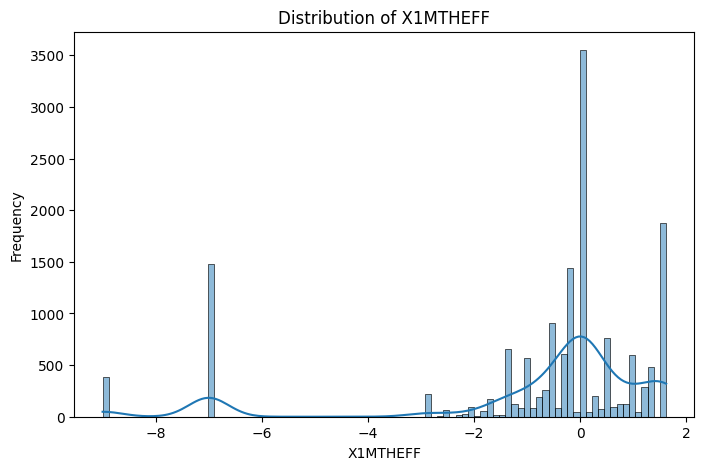

In [ ]:
plot_histogram(wave1, 'X1MTHEFF')

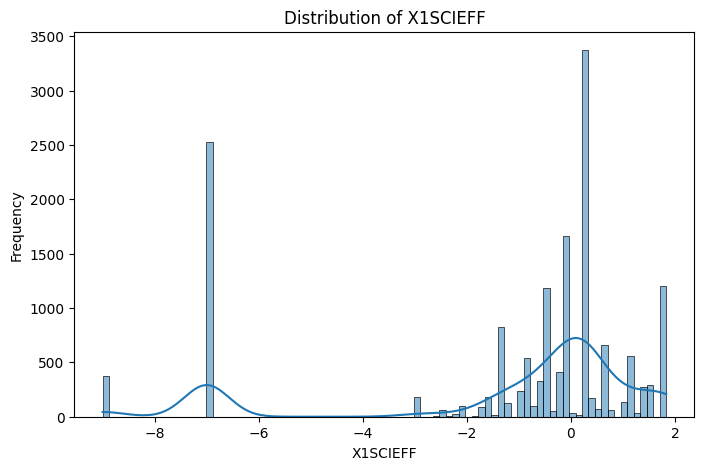

In [ ]:
plot_histogram(wave1, 'X1SCIEFF')

### Clean X1MTHEFF and X1SCIEFF

In [ ]:
# Convert flag columns from boolean to integer
wave1['MATH_NO_CLASS'] = wave1['MATH_NO_CLASS'].astype(int)
wave1['SCI_NO_CLASS']  = wave1['SCI_NO_CLASS'].astype(int)

# Replace both -7 (legitimate skip) and -9 (item missing) with NaN
wave1['X1MTHEFF'] = wave1['X1MTHEFF'].replace({-7: np.nan, -9: np.nan})
wave1['X1SCIEFF'] = wave1['X1SCIEFF'].replace({-7: np.nan, -9: np.nan})

print(f"X1MTHEFF missing after sentinel replacement: {wave1['X1MTHEFF'].isna().sum()}")
print(f"X1SCIEFF missing after sentinel replacement: {wave1['X1SCIEFF'].isna().sum()}")

# Impute only the -9 rows (flag == 0 and value is NaN)
# Rows that were -7 are left as NaN — the flag already represents them

for col, flag in [('X1MTHEFF', 'MATH_NO_CLASS'), ('X1SCIEFF', 'SCI_NO_CLASS')]:
    impute_mask = wave1[col].isna() & (wave1[flag] == 0)
    skewness    = wave1[col].skew()
    fill_value  = wave1[col].mean() if abs(skewness) < 1 else wave1[col].median()
    method      = 'mean' if abs(skewness) < 1 else 'median'
    wave1.loc[impute_mask, col] = fill_value

    print(f"\n{col}:")
    print(f"  Skewness       : {skewness:.4f}")
    print(f"  Method used    : {method}")
    print(f"  Value imputed  : {fill_value:.4f}")
    print(f"  Rows imputed   : {impute_mask.sum()}")
    print(f"  Remaining NaN  : {wave1[col].isna().sum()} (these are MATH_NO_CLASS/SCI_NO_CLASS rows)")

X1MTHEFF missing after sentinel replacement: 1864
X1SCIEFF missing after sentinel replacement: 2902

X1MTHEFF:
  Skewness       : -0.3712
  Method used    : mean
  Value imputed  : 0.0753
  Rows imputed   : 388
  Remaining NaN  : 1476 (these are MATH_NO_CLASS/SCI_NO_CLASS rows)

X1SCIEFF:
  Skewness       : -0.2337
  Method used    : mean
  Value imputed  : 0.0660
  Rows imputed   : 376
  Remaining NaN  : 2526 (these are MATH_NO_CLASS/SCI_NO_CLASS rows)


### Distribution After Cleaning

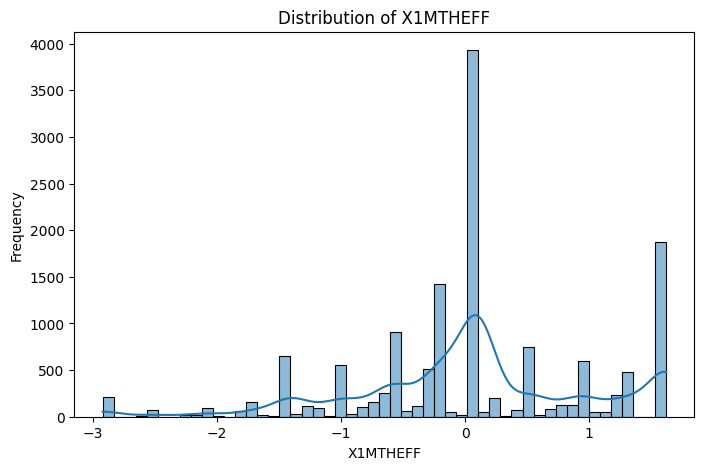

In [ ]:
plot_histogram(wave1, 'X1MTHEFF')

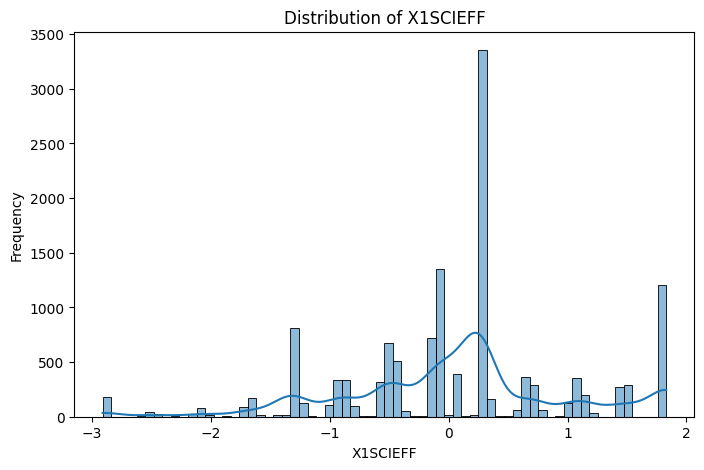

In [ ]:
plot_histogram(wave1, 'X1SCIEFF')

### X1TXMTSCOR — Verify No Cleaning Required

#### X1TXMTSCOR

- **Min / Max:** 24.0999 / 82.1876  
- **Count -9 (item skip):** 0 (0.00%)  
- **Count -8 (unit skip):** 0 (0.00%)  
- **Count -7 (legit skip):** 0 (0.00%)  
- **Count <= -4:** 0 (0.00%)  
- **Already NaN:** 0 (0.00%)  
- **TOTAL missing:** 0 (0.00%)  

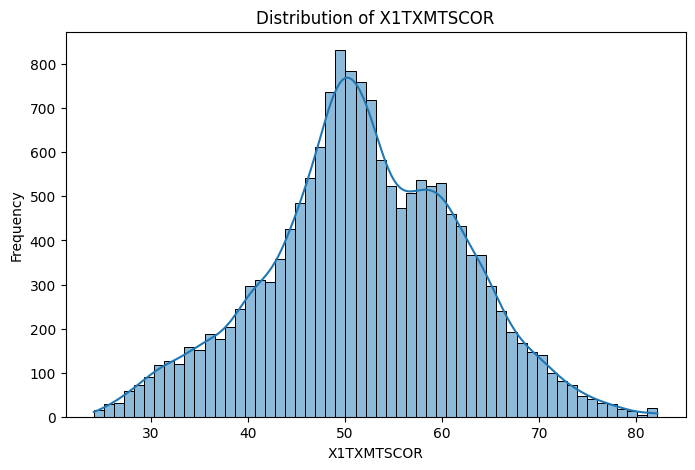

Sentinel codes in X1TXMTSCOR: 0
X1TXMTSCOR is clean — no sentinel codes present.


In [ ]:
plot_histogram(wave1, 'X1TXMTSCOR')
print(f"Sentinel codes in X1TXMTSCOR: {(wave1['X1TXMTSCOR'] < 0).sum()}")
print("X1TXMTSCOR is clean — no sentinel codes present.")

### X1SCHOOLBEL — School Belonging Scale

#### X1SCHOOLBEL

- **Min / Max:** -9.0 / 1.59  
- **Count -9 (item skip):** 522 (3.28%)  
- **Count -8 (unit skip):** 0 (0.00%)  
- **Count -7 (legit skip):** 0 (0.00%)  
- **Count <= -4:** 542 (3.41%)  
- **Already NaN:** 0 (0.00%)  
- **TOTAL missing:** 522 (3.28%)  

**Sentinel present:** -9 only (item non-response). No -7 or -8 codes are present.

The valid range extends below -4 (the scale includes legitimate negative scores), which was verified by inspecting the distribution of values in the range -5 to -4. These are real student scores, not mislabeled sentinels.

**Imputation strategy:** Median, because the distribution has a visible left tail.

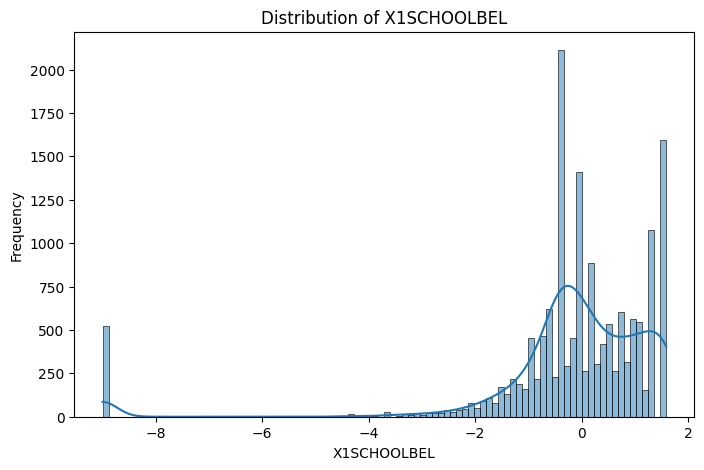

In [ ]:
plot_histogram(wave1, 'X1SCHOOLBEL')

In [ ]:
# Confirm the range of values below -4 (distinguishing real scores from sentinel -9)
weird_vals = wave1['X1SCHOOLBEL'][
    (wave1['X1SCHOOLBEL'] <= -4) & (wave1['X1SCHOOLBEL'] != -9)
]
print("Values below -4 that are not -9 (these are real scores):")
print(weird_vals.value_counts())

Values below -4 that are not -9 (these are real scores):
X1SCHOOLBEL
-4.35    15
-4.02     2
-4.00     2
-4.10     1
Name: count, dtype: int64


In [ ]:
wave1['X1SCHOOLBEL'] = wave1['X1SCHOOLBEL'].replace(-9, np.nan)
fill_value = wave1['X1SCHOOLBEL'].median()
wave1['X1SCHOOLBEL'] = wave1['X1SCHOOLBEL'].fillna(fill_value)

print(f"Imputed with median: {fill_value:.4f}")
print(f"Missing remaining  : {wave1['X1SCHOOLBEL'].isna().sum()}")

Imputed with median: -0.0400
Missing remaining  : 0


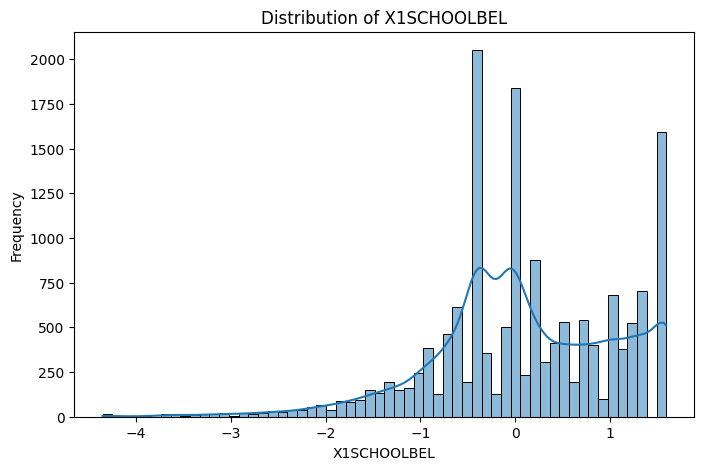

In [ ]:
plot_histogram(wave1, 'X1SCHOOLBEL')

### X1SCHOOLCLI — School Climate Scale

#### X1SCHOOLCLI

- **Min / Max:** -9.0 / 1.97  
- **Count -9 (item skip):** 2351 (14.79%)  
- **Count -8 (unit skip):** 844 (5.31%)  
- **Count -7 (legit skip):** 0 (0.00%)  
- **Count <= -4:** 3226 (20.29%)  
- **Already NaN:** 0 (0.00%)  
- **TOTAL missing:** 3195 (20.09%)  

**Sentinels present:** -9 (item non-response) and -8 (unit non-response).

Before deciding how to handle these, we check whether either sentinel group shows a significantly different dropout rate. If they do, a flag column is needed. If they do not, both can simply be replaced with NaN and imputed.

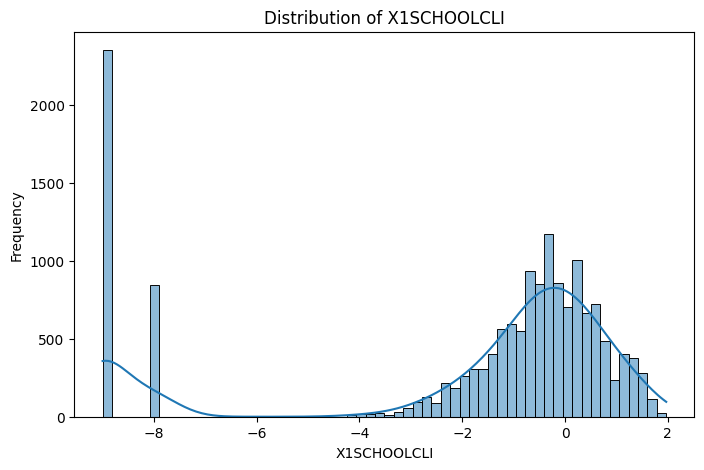

In [ ]:
plot_histogram(wave1, 'X1SCHOOLCLI')

In [ ]:
# Inspect values below -4 to separate real scores from sentinels
weird_vals = wave1['X1SCHOOLCLI'][
    (wave1['X1SCHOOLCLI'] <= -4) & (~wave1['X1SCHOOLCLI'].isin([-9, -8]))
]
print("Values below -4 that are not -9 or -8 (real scores near the lower boundary):")
print(weird_vals.value_counts())

Values below -4 that are not -9 or -8 (real scores near the lower boundary):
X1SCHOOLCLI
-4.00    20
-4.22    11
Name: count, dtype: int64


In [ ]:
# Check whether -8 or -9 groups have meaningfully different dropout rates
print("=== Dropout Rate by Sentinel Group ===\n")

for val, label in [(-9, 'Item missing (-9)'), (-8, 'Unit non-response (-8)')]:
    mask  = wave1['X1SCHOOLCLI'] == val
    count = mask.sum()
    rate  = wave1[mask]['X4EVERDROP'].mean()
    print(f"  [{label}]")
    print(f"  Count        : {count}")
    print(f"  Dropout rate : {rate:.2%}\n")

valid_mask = ~wave1['X1SCHOOLCLI'].isin([-9, -8])
rate_valid  = wave1[valid_mask]['X4EVERDROP'].mean()
print(f"  [Valid scores]")
print(f"  Count        : {valid_mask.sum()}")
print(f"  Dropout rate : {rate_valid:.2%}")

flag_8 = (wave1['X1SCHOOLCLI'] == -8).astype(int)
c, p, _, _ = chi2_contingency(pd.crosstab(flag_8, wave1['X4EVERDROP']))
print(f"\n  Chi-square p-value (-8 vs rest): {p:.4f}")

flag_9 = (wave1['X1SCHOOLCLI'] == -9).astype(int)
c, p, _, _ = chi2_contingency(pd.crosstab(flag_9, wave1['X4EVERDROP']))
print(f"  Chi-square p-value (-9 vs rest): {p:.4f}")

=== Dropout Rate by Sentinel Group ===

  [Item missing (-9)]
  Count        : 2351
  Dropout rate : 16.50%

  [Unit non-response (-8)]
  Count        : 844
  Dropout rate : 16.23%

  [Valid scores]
  Count        : 12705
  Dropout rate : 15.10%

  Chi-square p-value (-8 vs rest): 0.5034
  Chi-square p-value (-9 vs rest): 0.1036


Neither sentinel group shows a statistically significant dropout rate difference. No flag column is needed. Both -9 and -8 are replaced with NaN and imputed using the mean (distribution is approximately symmetric).

In [ ]:
wave1['X1SCHOOLCLI'] = wave1['X1SCHOOLCLI'].replace({-9: np.nan, -8: np.nan})

skewness   = wave1['X1SCHOOLCLI'].skew()
fill_value = wave1['X1SCHOOLCLI'].mean() if abs(skewness) < 1 else wave1['X1SCHOOLCLI'].median()
method     = 'mean' if abs(skewness) < 1 else 'median'

wave1['X1SCHOOLCLI'] = wave1['X1SCHOOLCLI'].fillna(fill_value)

print(f"Skewness      : {skewness:.4f}")
print(f"Method used   : {method}")
print(f"Value imputed : {fill_value:.4f}")
print(f"Missing remaining: {wave1['X1SCHOOLCLI'].isna().sum()}")

Skewness      : -0.4775
Method used   : mean
Value imputed : -0.3591
Missing remaining: 0


### Outlier Inspection — All Continuous Columns

Boxplots are used to identify statistical outliers (points beyond 1.5 * IQR from the box edges). For all five standardized scale variables, extreme values represent real students with genuinely high or low scores, not data errors. These outliers are not removed for two reasons:

1. The variables are standardized PCA scores produced by NCES. Extreme values are mathematically valid.
2. Students with very low math self-efficacy, school belonging, or school climate scores are precisely the students most relevant to predicting dropout. Removing them would degrade model performance.

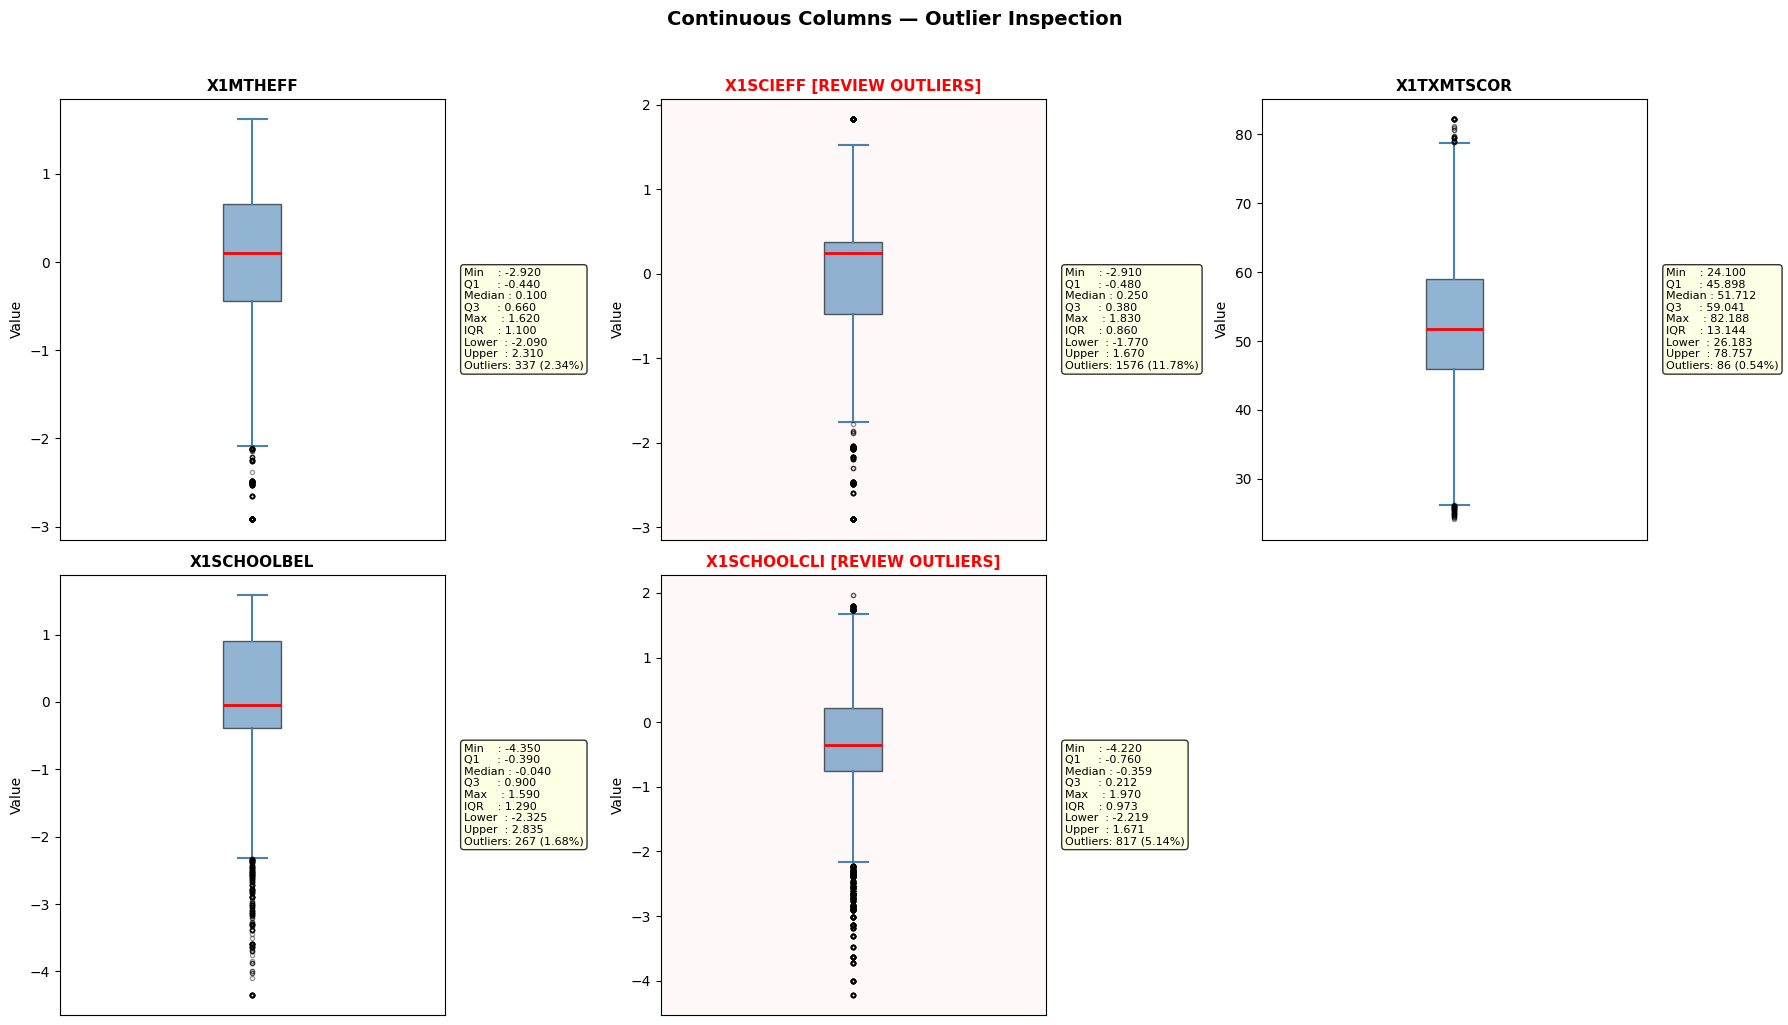

In [ ]:
plot_boxplot(
    df    = wave1,
    cols  = continuous_cols,
    title = 'Continuous Columns — Outlier Inspection'
)

### Boxplot Interpretation

| Variable | Outliers | Decision |
|----------|----------|----------|
| `X1MTHEFF` | 2.34% (lower tail only) | Retain — real students with low math self-efficacy |
| `X1SCIEFF` | 11.78% (both tails) | Retain — standardized PCA scale; extreme scores are mathematically valid |
| `X1TXMTSCOR` | 0.54% | Retain — very few, both tails; normal for a test score |
| `X1SCHOOLBEL` | 1.68% (lower tail) | Retain — students with very low school belonging |
| `X1SCHOOLCLI` | 5.14% (lower tail) | Retain — schools with poor climate; borderline but real variation |

---
## 8.2 Ordinal Variables

### Diagnostic — Sentinel Inspection

In [ ]:
sentinel_codes = [-9, -8, -7, -6, -5, -4]

print("=" * 70)
print("  ORDINAL COLUMNS — SENTINEL DIAGNOSTIC")
print("=" * 70)

ordinal_cols_clean = [
    'S1M8GRADE', 'S1S8GRADE', 'S1EDUEXPECT',
    'S1SUREHSGRAD', 'S1PAYOFF', 'S1GETINTOCLG',
    'S1AFFORD', 'S1WORKING'
]

for col in ordinal_cols_clean:
    total      = len(wave1[col])
    valid_mask = ~wave1[col].isin(sentinel_codes)
    valid_vals = wave1[col][valid_mask]
    valid_total = valid_mask.sum()

    print(f"\n  {col}")
    print(f"  Valid range   : {valid_vals.min()} to {valid_vals.max()}")
    print(f"  Valid count   : {valid_total} ({valid_total/total*100:.2f}%)")

    any_sentinel = False
    for code in sentinel_codes:
        count = (wave1[col] == code).sum()
        if count > 0:
            print(f"  Sentinel {code}  : {count} rows ({count/total*100:.2f}%)")
            any_sentinel = True
    if not any_sentinel:
        print(f"  No sentinels found")

  ORDINAL COLUMNS — SENTINEL DIAGNOSTIC

  S1M8GRADE
  Valid range   : 1.0 to 6.0
  Valid count   : 15597 (98.09%)
  Sentinel -9  : 221 rows (1.39%)
  Sentinel -7  : 82 rows (0.52%)

  S1S8GRADE
  Valid range   : 1.0 to 6.0
  Valid count   : 15417 (96.96%)
  Sentinel -9  : 401 rows (2.52%)
  Sentinel -7  : 82 rows (0.52%)

  S1EDUEXPECT
  Valid range   : 1.0 to 11.0
  Valid count   : 15715 (98.84%)
  Sentinel -9  : 185 rows (1.16%)

  S1SUREHSGRAD
  Valid range   : 1.0 to 4.0
  Valid count   : 15534 (97.70%)
  Sentinel -9  : 366 rows (2.30%)

  S1PAYOFF
  Valid range   : 1.0 to 4.0
  Valid count   : 15639 (98.36%)
  Sentinel -9  : 261 rows (1.64%)

  S1GETINTOCLG
  Valid range   : 1.0 to 4.0
  Valid count   : 15605 (98.14%)
  Sentinel -9  : 295 rows (1.86%)

  S1AFFORD
  Valid range   : 1.0 to 4.0
  Valid count   : 15557 (97.84%)
  Sentinel -9  : 343 rows (2.16%)

  S1WORKING
  Valid range   : 1.0 to 4.0
  Valid count   : 15517 (97.59%)
  Sentinel -9  : 383 rows (2.41%)


### Visualize Ordinal Distributions Before Cleaning

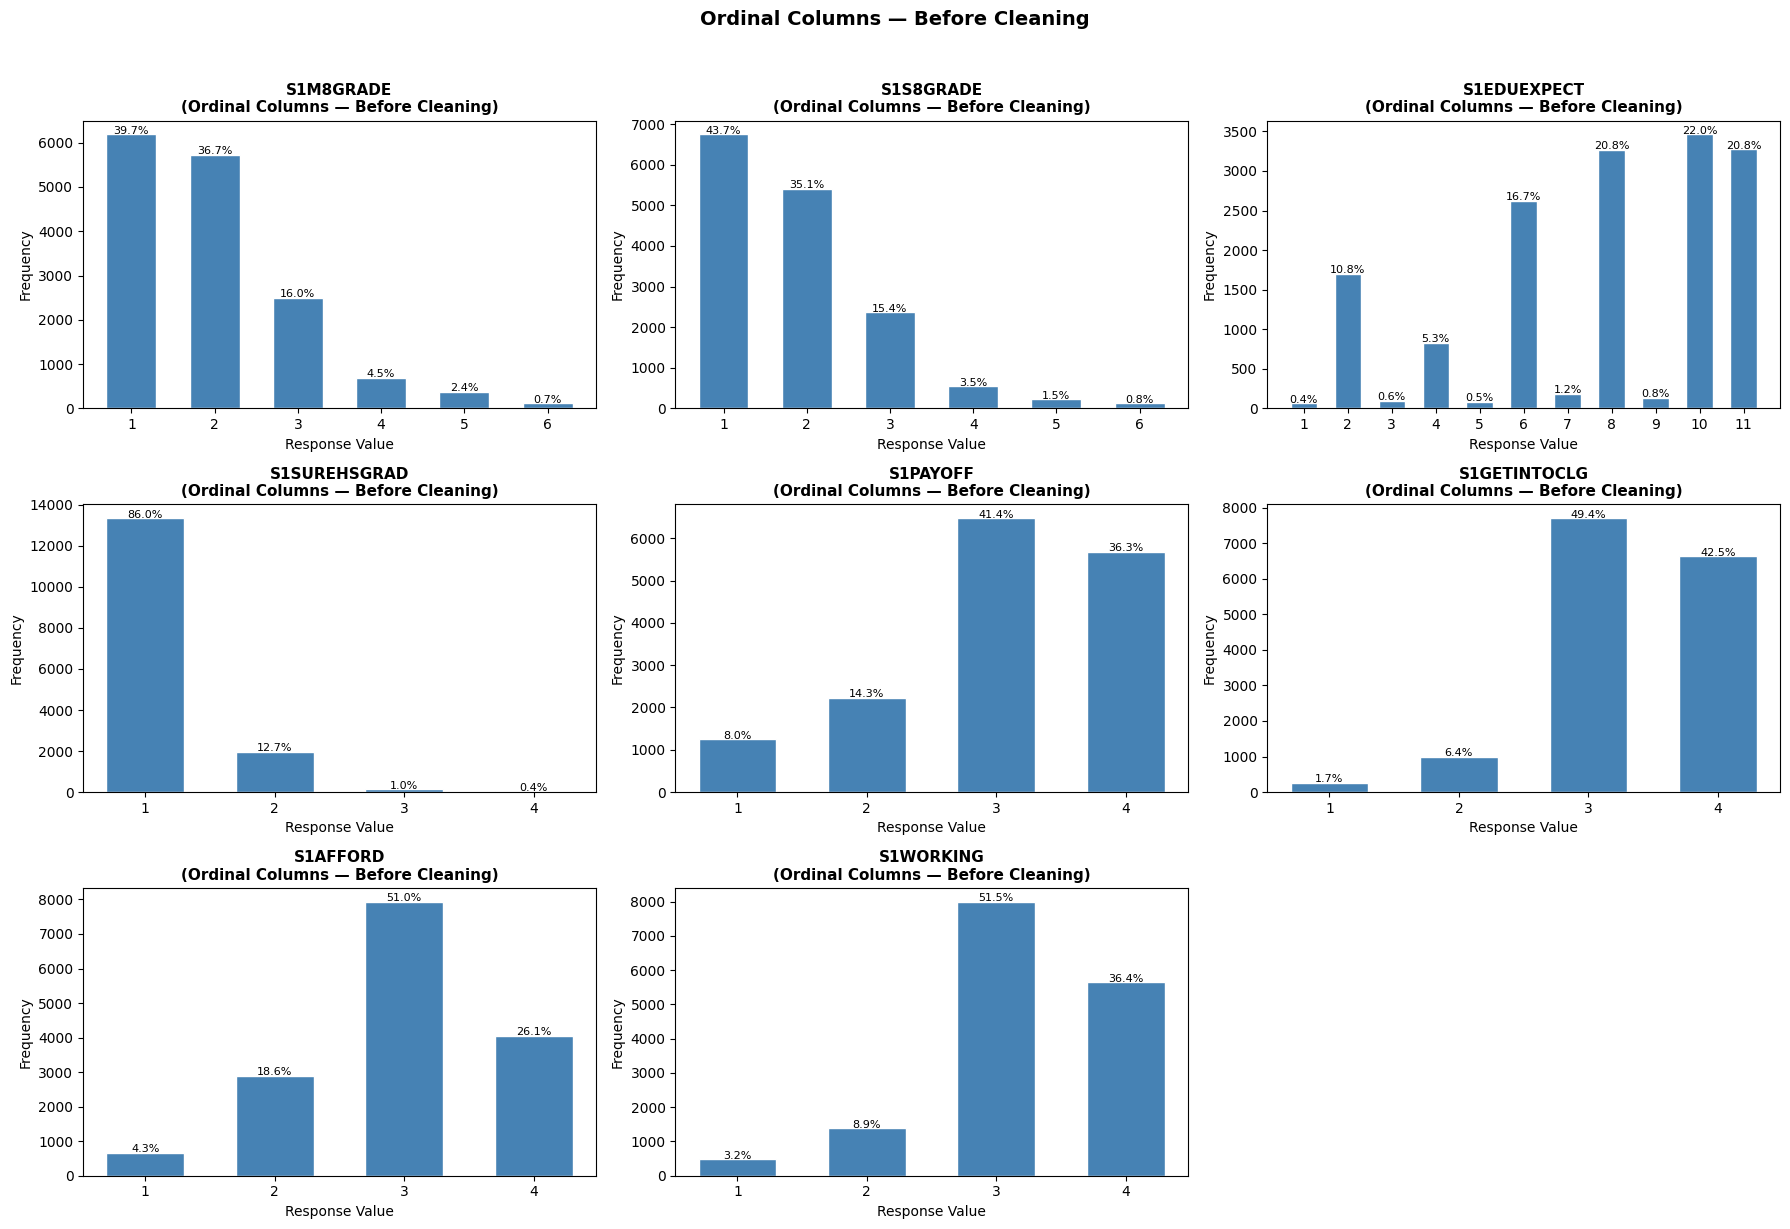

In [ ]:
plot_ordinal(
    df                = wave1,
    cols              = ordinal_cols_clean,
    title             = 'Ordinal Columns — Before Cleaning',
    color             = 'steelblue',
    exclude_sentinels = True
)

### Clean All Ordinal Columns

**Strategy:** Replace all sentinel codes with NaN, then impute using the mode (most frequent valid value). Mode is the correct central tendency measure for ordinal data — mean would imply equal spacing between categories, which is not guaranteed.

In [ ]:
print("=== Cleaning Ordinal Columns ===\n")

for col in ordinal_cols_clean:
    before   = wave1[col].isin(sentinel_codes).sum()
    wave1[col] = wave1[col].replace(sentinel_codes, np.nan)
    mode_val   = wave1[col].mode()[0]
    wave1[col] = wave1[col].fillna(mode_val).astype(int)

    print(f"  {col}:")
    print(f"    Rows imputed : {before}")
    print(f"    Mode used    : {mode_val}")
    print(f"    Missing now  : {wave1[col].isna().sum()}")
    print()

print("All ordinal columns cleaned.")

=== Cleaning Ordinal Columns ===

  S1M8GRADE:
    Rows imputed : 303
    Mode used    : 1.0
    Missing now  : 0

  S1S8GRADE:
    Rows imputed : 483
    Mode used    : 1.0
    Missing now  : 0

  S1EDUEXPECT:
    Rows imputed : 185
    Mode used    : 10.0
    Missing now  : 0

  S1SUREHSGRAD:
    Rows imputed : 366
    Mode used    : 1.0
    Missing now  : 0

  S1PAYOFF:
    Rows imputed : 261
    Mode used    : 3.0
    Missing now  : 0

  S1GETINTOCLG:
    Rows imputed : 295
    Mode used    : 3.0
    Missing now  : 0

  S1AFFORD:
    Rows imputed : 343
    Mode used    : 3.0
    Missing now  : 0

  S1WORKING:
    Rows imputed : 383
    Mode used    : 3.0
    Missing now  : 0

All ordinal columns cleaned.


### Visualize Ordinal Distributions After Cleaning

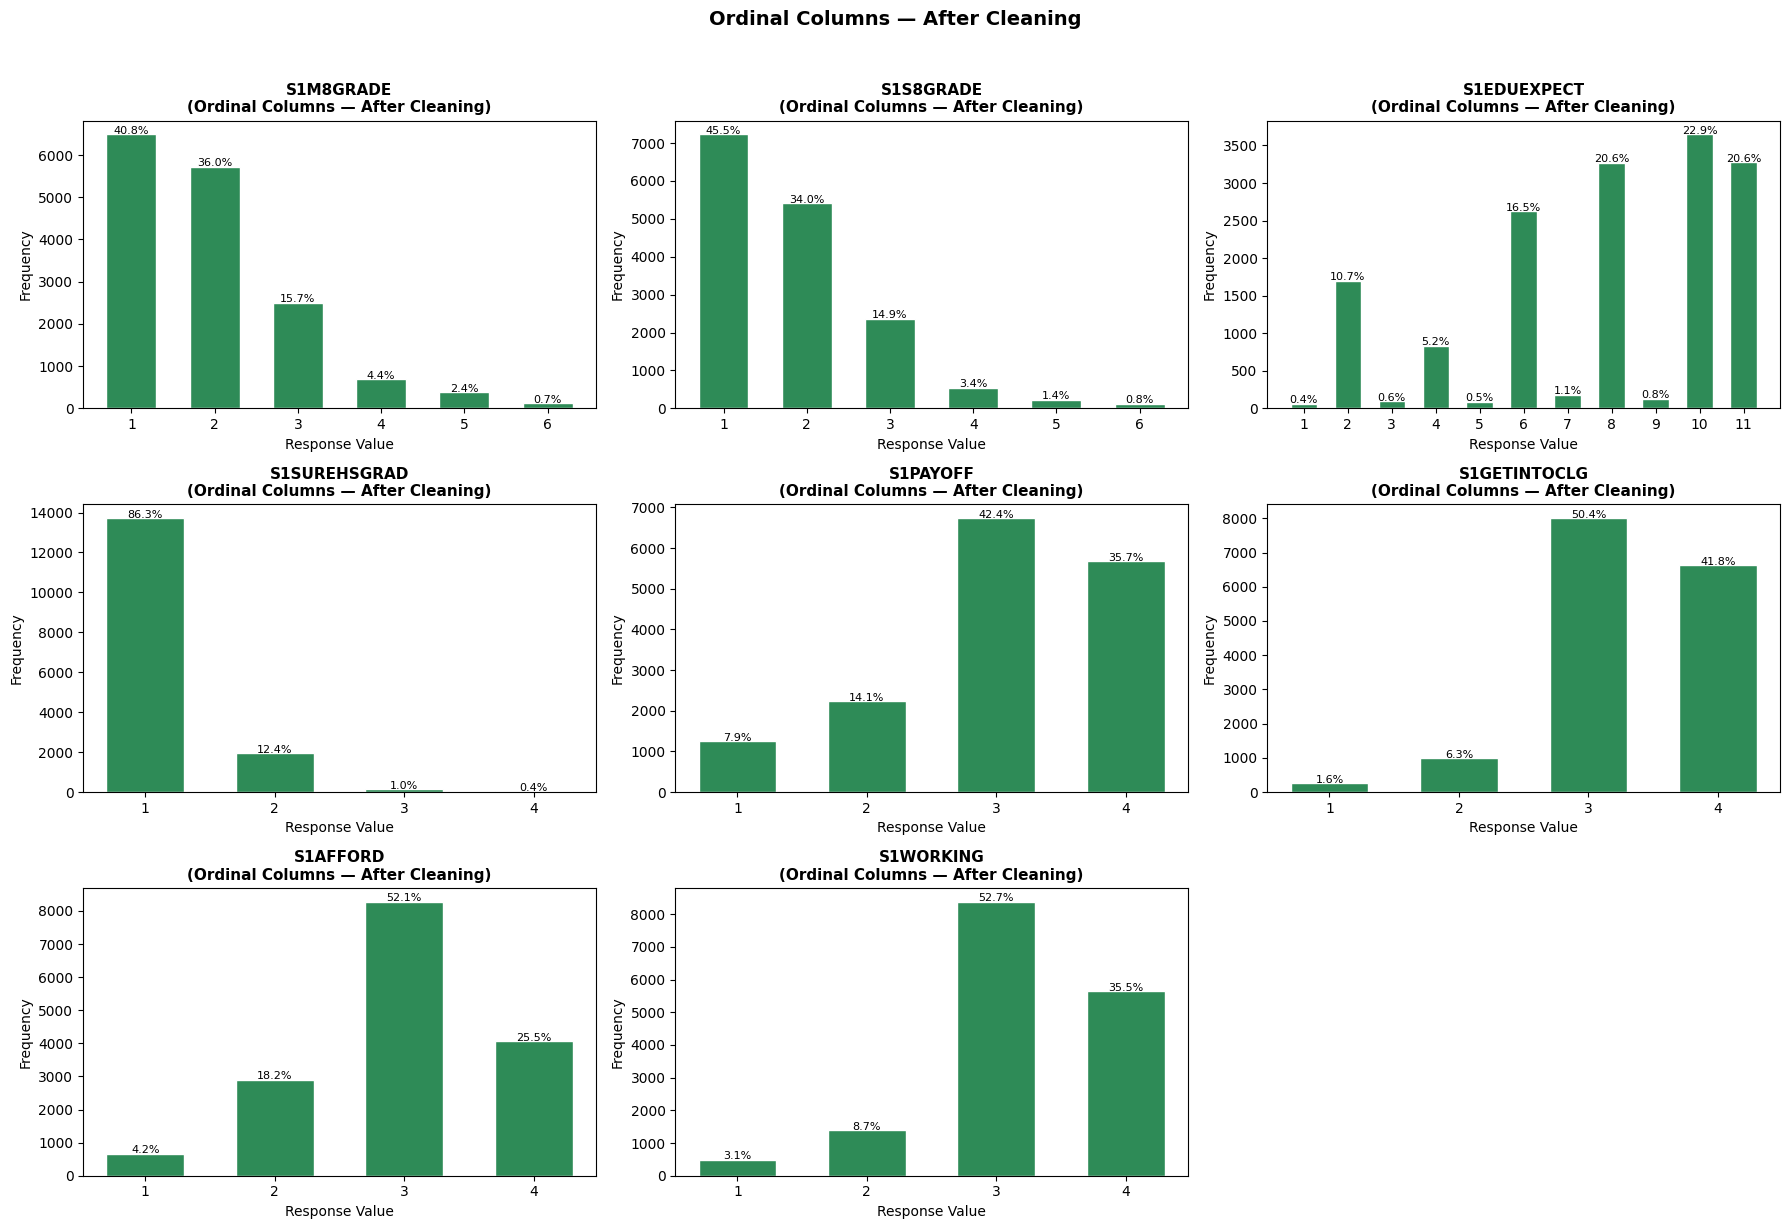

In [ ]:
plot_ordinal(
    df                = wave1,
    cols              = ordinal_cols_clean,
    title             = 'Ordinal Columns — After Cleaning',
    color             = 'seagreen',
    exclude_sentinels = False
)

---
## 8.3 Nominal Variables

Nominal variables are inspected for sentinel codes here. No imputation is applied at this stage — cleaning is handled and one-hot encoding is applied in Section 11 (Preprocessing for Modeling).

In [ ]:
nominal_cols = ['X1RACE', 'X1LOCALE', 'X1REGION']

print("=" * 70)
print("  NOMINAL COLUMNS — VALUE DISTRIBUTION")
print("=" * 70)

for col in nominal_cols:
    counts = wave1[col].value_counts(dropna=False).sort_index()
    total  = counts.sum()
    print(f"\n  {col}:")
    for val, count in counts.items():
        label = 'NaN' if pd.isna(val) else val
        print(f"    {label:>6} -> {count:>6} ({count/total*100:.1f}%)")

  NOMINAL COLUMNS — VALUE DISTRIBUTION

  X1RACE:
       1.0 ->    117 (0.7%)
       2.0 ->   1295 (8.1%)
       3.0 ->   1631 (10.3%)
       4.0 ->    135 (0.8%)
       5.0 ->   2346 (14.8%)
       6.0 ->   1394 (8.8%)
       7.0 ->     70 (0.4%)
       8.0 ->   8912 (56.1%)

  X1LOCALE:
       1.0 ->   4584 (28.8%)
       2.0 ->   5742 (36.1%)
       3.0 ->   1823 (11.5%)
       4.0 ->   3751 (23.6%)

  X1REGION:
       1.0 ->   2491 (15.7%)
       2.0 ->   4315 (27.1%)
       3.0 ->   6370 (40.1%)
       4.0 ->   2724 (17.1%)


---
## 8.4 Binary Variables

### Diagnostic — Sentinel Inspection and Class Balance

In [ ]:
sentinel_codes = [-9, -8, -7, -6, -5, -4]
binary_cols_inspect = ['X1CONTROL', 'X2SEX']

print("=" * 70)
print("  BINARY COLUMNS — SENTINEL DIAGNOSTIC")
print("=" * 70)

for col in binary_cols_inspect:
    total      = len(wave1[col])
    valid_mask = ~wave1[col].isin(sentinel_codes) & wave1[col].notna()
    valid_vals = wave1[col][valid_mask]
    valid_total = valid_mask.sum()

    print(f"\n  {col}")
    print(f"  Valid range  : {int(valid_vals.min())} to {int(valid_vals.max())}")
    print(f"  Valid count  : {valid_total} ({valid_total/total*100:.2f}%)")

    for code in sentinel_codes:
        count = (wave1[col] == code).sum()
        if count > 0:
            print(f"  Sentinel {code}: {count} rows ({count/total*100:.2f}%)")

    val_counts   = valid_vals.value_counts().sort_index()
    minority_pct = val_counts.min() / valid_total * 100
    majority_pct = val_counts.max() / valid_total * 100
    print(f"  Balance      : {majority_pct:.1f}% / {minority_pct:.1f}%")

  BINARY COLUMNS — SENTINEL DIAGNOSTIC

  X1CONTROL
  Valid range  : 1 to 2
  Valid count  : 15900 (100.00%)
  Balance      : 81.0% / 19.0%

  X2SEX
  Valid range  : 1 to 2
  Valid count  : 15900 (100.00%)
  Balance      : 51.4% / 48.6%


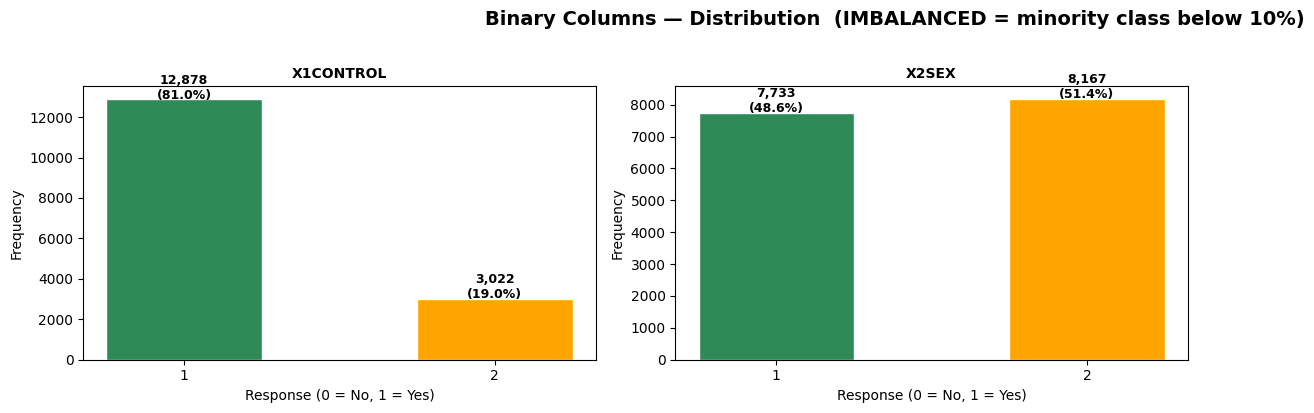

In [ ]:
plot_binary(
    df    = wave1,
    cols  = ['X1CONTROL', 'X2SEX'],
    title = 'Binary Columns — Distribution'
)


#### Post-High School Plan Variables

The dataset includes 10 binary indicators (S1FY*) recording whether a student planned, in 9th grade, to pursue each of the following paths in their first year after high school.

Each variable is coded 1 (yes) or 0 (no). Missing values (-9) are imputed using domain logic:

- For the 9 specific path variables (e.g., `S1FYJOB`, `S1FYMILITARY`): a missing response is treated as 0, meaning the student did not indicate that path as a plan.
- For `S1FYNOTSURE`: a missing response is treated as 1, since a student who did not answer the question about being unsure is better grouped with students who said they were unsure than with students who had a definite plan.

In [ ]:
plan_cols = [
    "S1FYAA",       # Plans to enroll in an Associate's degree program
    "S1FYBA",       # Plans to enroll in a Bachelor's degree program
    "S1FYLICENSE",  # Plans to obtain a license or certificate
    "S1FYAPPR",     # Plans to attend a registered apprenticeship
    "S1FYMILITARY", # Plans to join the armed services
    "S1FYJOB",      # Plans to get a job
    "S1FYFAMILY",   # Plans to start or help with family
    "S1FYTRAVEL",   # Plans to travel
    "S1FYVOLUN",    # Plans to volunteer or do missionary work
    "S1FYNOTSURE"   # Not sure what to do after high school
]

In [ ]:
specific_path_cols = [
    'S1FYAA', 'S1FYBA', 'S1FYLICENSE', 'S1FYAPPR',
    'S1FYMILITARY', 'S1FYJOB', 'S1FYFAMILY', 'S1FYTRAVEL', 'S1FYVOLUN'
]

# -9 on specific paths → 0 (no plan indicated)
wave1[specific_path_cols] = wave1[specific_path_cols].replace(-9.0, 0.0)

# -9 on S1FYNOTSURE → 1 (grouped with "not sure")
wave1['S1FYNOTSURE'] = wave1['S1FYNOTSURE'].replace(-9.0, 1.0)

print("Post-HS plan variables imputed.")
print("S1FYNOTSURE value counts after imputation:")
print(wave1['S1FYNOTSURE'].value_counts().sort_index())

Post-HS plan variables imputed.
S1FYNOTSURE value counts after imputation:
S1FYNOTSURE
0.0    13713
1.0     2187
Name: count, dtype: int64


### Correlation of Binary Plan Variables with Dropout Target

In [ ]:
from scipy.stats import pointbiserialr

binary_plan_cols = [
    'S1FYAA', 'S1FYBA', 'S1FYLICENSE', 'S1FYAPPR',
    'S1FYMILITARY', 'S1FYJOB', 'S1FYFAMILY',
    'S1FYTRAVEL', 'S1FYVOLUN', 'S1FYNOTSURE', 'X1CONTROL'
]

results = []
for col in binary_plan_cols:
    corr, pval = pointbiserialr(wave1[col], wave1['X4EVERDROP'])
    rate_0 = wave1[wave1[col] == 0]['X4EVERDROP'].mean()
    rate_1 = wave1[wave1[col] == 1]['X4EVERDROP'].mean()
    results.append({
        'Column': col, 'Correlation': corr, 'Abs_Corr': abs(corr),
        'P_value': pval, 'Dropout_0': rate_0, 'Dropout_1': rate_1,
        'Difference': rate_1 - rate_0, 'Significant': 'Yes' if pval < 0.05 else 'No'
    })

results_df = pd.DataFrame(results).sort_values('Abs_Corr', ascending=False).reset_index(drop=True)
results_df.index += 1

print("=" * 75)
print("  BINARY COLUMNS — CORRELATION WITH DROPOUT (Ranked)")
print("=" * 75)
print(f"  {'Rank':<5} {'Column':<20} {'Corr':>7} {'P-val':>8} {'Sig':>5} {'Drop=0':>8} {'Drop=1':>8}")
print(f"  {'─'*5} {'─'*20} {'─'*7} {'─'*8} {'─'*5} {'─'*8} {'─'*8}")

for rank, row in results_df.iterrows():
    direction = 'up' if row['Difference'] > 0 else 'down'
    print(f"  {rank:<5} {row['Column']:<20} {row['Correlation']:>7.4f} {row['P_value']:>8.4f}"
          f" {row['Significant']:>5} {row['Dropout_0']:>7.2%} {row['Dropout_1']:>7.2%}")

  BINARY COLUMNS — CORRELATION WITH DROPOUT (Ranked)
  Rank  Column                  Corr    P-val   Sig   Drop=0   Drop=1
  ───── ──────────────────── ─────── ──────── ───── ──────── ────────
  1     S1FYBA               -0.1776   0.0000   Yes  22.38%   9.52%
  2     X1CONTROL            -0.1419   0.0000   Yes    nan%  17.84%
  3     S1FYJOB               0.0710   0.0000   Yes  13.27%  18.49%
  4     S1FYFAMILY            0.0688   0.0000   Yes  14.74%  25.16%
  5     S1FYMILITARY          0.0627   0.0000   Yes  14.72%  23.24%
  6     S1FYVOLUN            -0.0361   0.0000   Yes  15.77%  11.18%
  7     S1FYNOTSURE           0.0258   0.0011   Yes  14.99%  17.70%
  8     S1FYAA                0.0242   0.0023   Yes  15.00%  17.45%
  9     S1FYTRAVEL            0.0200   0.0118   Yes  15.10%  17.33%
  10    S1FYLICENSE           0.0180   0.0236   Yes  15.13%  17.12%
  11    S1FYAPPR             -0.0040   0.6162    No  15.39%  14.55%


---
# Section 9 — Save EDA-Ready Dataset

At this point, all sentinel codes have been resolved, obvious non-informative columns have been removed, and the basic structure of the dataset is clean. This version is suitable for Exploratory Data Analysis.

Note that nominal variables (`X1RACE`, `X1LOCALE`, `X1REGION`) have not yet been encoded — they remain in their original integer category form, which is appropriate for EDA visualizations.

In [ ]:
print(f"Final column count : {wave1.shape[1]}")
print(f"Final row count    : {wave1.shape[0]}")
print(f"Remaining NaN      : {wave1.isnull().sum().sum()}")
print()
print(wave1.columns.tolist())

Final column count : 39
Final row count    : 15900
Remaining NaN      : 19087

['X4EVERDROP', 'X1MTHEFF', 'X1SCIEFF', 'X1TXMTSCOR', 'S1M8GRADE', 'S1S8GRADE', 'X1PAREDU', 'X1PAREDEXPCT', 'X1POVERTY', 'X1FAMINCOME', 'S1PLAN', 'S1EDUEXPECT', 'S1SUREHSGRAD', 'S1PAYOFF', 'S1GETINTOCLG', 'S1AFFORD', 'S1WORKING', 'X1SCHOOLBEL', 'X1SCHOOLCLI', 'X1LOCALE', 'X1RACE', 'X2SEX', 'X1CONTROL', 'X1REGION', 'S1FYAA', 'S1FYBA', 'S1FYLICENSE', 'S1FYAPPR', 'S1FYMILITARY', 'S1FYJOB', 'S1FYFAMILY', 'S1FYTRAVEL', 'S1FYVOLUN', 'S1FYNOTSURE', 'STU_ID', 'X1PAR_SURVEY_MISSING', 'X1_DUAL_PARENT', 'MATH_NO_CLASS', 'SCI_NO_CLASS']


In [ ]:
wave1.to_csv("9thCLEANED.csv", index=False)
print("Saved: 9thCLEANED.csv — ready for EDA")

Saved: 9thCLEANED.csv — ready for EDA
